## Hierarchical Clustering — Practical Implementation

## 🎯 What Are We Trying To Do?
Imagine you own a business and have customer data.

But:  Nobody told you:

1.who are premium customers 
2.who are budget customers 
3.who are inactive customers

Now the question becomes:

Can the algorithm automatically discover groups of similar people?

That is clustering.

##  What Is Agglomerative Clustering?

This is the most common type.

 “Agglomerative” means:

merging things together

#  How It Works

Initially:

A   B   C   D

Every point is its own cluster.

## Then algorithm checks:

👉 Which two points are MOST similar?

Suppose:

B and C are closest

Then:

A   (B,C)   D

Then it merges again.

This continues until:

👉 everything becomes ONE cluster.

##  What Dataset Are We Using?

A very small dataset intentionally.

Why?

Because:
👉 You should SEE the clustering happening.

Not blindly run algorithms on huge data.

🧠 What Will Happen In Our Dataset?

We’ll create customers with:

1.Income
2.Spending score

## You should EXPECT:

1. Low-income people grouping together
2. High-income people grouping together

In [43]:
# Step 1: Create Dataset

import pandas as pd

data = {
    'Income': [15, 16, 17, 18, 60, 62, 64, 65],
    'Spending': [20, 22, 19, 18, 80, 82, 78, 79]
}

df = pd.DataFrame(data)

df

,Income,Spending
0,15,20
1,16,22
2,17,19
3,18,18
4,60,80
5,62,82
6,64,78
7,65,79


##  The 2 Natural Groups You Saw
Group 1

Low income + low spending

15,20
16,22
17,19
18,18
Group 2

High income + high spending

60,80
62,82
64,78
65,79

##  IMPORTANT LEARNING

👉 Clustering is NOT prediction.

There is:

no success/failure,
no labels,
no target variable.

The algorithm itself tries to discover:
👉 “which points are similar?”

##  Building the Dendrogram

In [44]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

 ## What Is linkage()?

This is the brain of clustering.

It calculates:

* which points should merge.

 What Is dendrogram()?

This creates:

1. the tree visualization.

In [45]:
linked = linkage(df, method='ward')

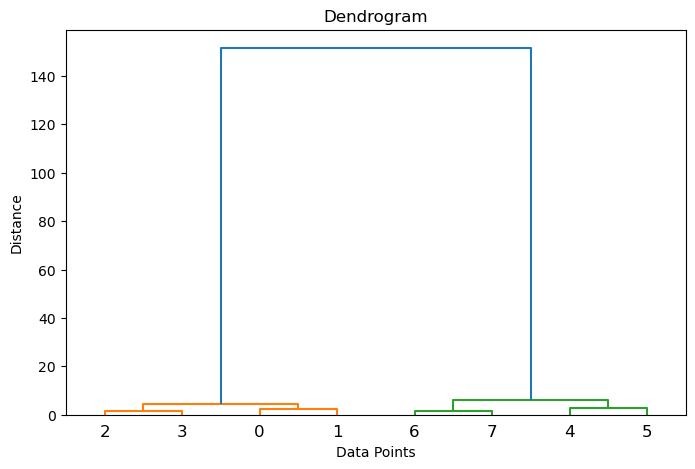

In [46]:
## Plot Dendrogram

plt.figure(figsize=(8,5))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

##  Agglomerative Clustering (Practical Application)

In [47]:
from sklearn.cluster import AgglomerativeClustering

In [48]:
#Create Clusters

model = AgglomerativeClustering(n_clusters=2)

clusters = model.fit_predict(df)

In [49]:
# What Will clusters Contain?

#Something like:

[1, 1, 1, 1, 0, 0, 0, 0]

#Meaning:

#first 4 points → one cluster
#next 4 points → another cluster

[1, 1, 1, 1, 0, 0, 0, 0]

In [50]:
df['Cluster'] = clusters

df

,Income,Spending,Cluster
0,15,20,1
1,16,22,1
2,17,19,1
3,18,18,1
4,60,80,0
5,62,82,0
6,64,78,0
7,65,79,0


## Now we should VISUALIZE the clusters.


Because clustering becomes MUCH clearer visually.

You’ll literally SEE:

1.low-income cluster,
2.high-income cluster

## What Are We Trying To Do?

We want a graph where:

each point = one customer,
color = cluster

So we can visually verify:

👉 Did the algorithm group similar points correctly?

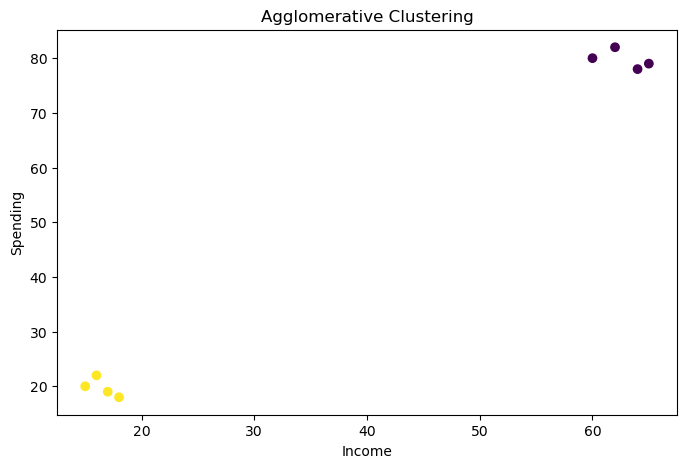

In [51]:
#scatter Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df['Income'],
    df['Spending'],
    c=df['Cluster']
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Agglomerative Clustering")

plt.show()

# 📊 Cluster Visualization Interpretation

The scatter plot provides a visual representation of how Agglomerative Clustering groups similar data points together.

Each point in the graph represents a customer based on:
- **Income**
- **Spending**

The colors indicate the cluster assigned by the algorithm.

---

##  Key Observation

The algorithm successfully identified **two natural groups**:

###  Cluster 1
Customers with:
- Lower income
- Lower spending

These points are located close to each other in the lower-left region of the graph.

---

###  Cluster 2
Customers with:
- Higher income
- Higher spending

These points form another tightly packed group in the upper-right region.

---

##  Important Insight

Clustering works based on **distance and similarity**.

- Points that are **close together** behave similarly
- Points that are **far apart** behave differently

Since the two groups are separated by a large distance, the algorithm identified them as separate clusters.

---

##  Connection to Dendrogram

This also explains why the dendrogram showed a very large final merge distance.

The algorithm considered the two groups highly different, so they were merged only at a much higher distance level.

---

## 🎯 Final Understanding

Agglomerative Clustering:
- Starts with individual data points
- Merges the most similar points step-by-step
- Forms clusters based on similarity and distance

The visualization confirms that the algorithm correctly grouped customers with similar income and spending behavior.

## FEATURE SCALING

# 🧠 Why Are We Learning Feature Scaling?

Right now, our dataset looks like this:

| Income | Spending |
|--------|----------|
| 15 | 20 |
| 65 | 80 |

Both features are somewhat similar in scale.

Because of this, clustering works nicely and both features contribute fairly while calculating distance.

---

# 🚨 But Real-World Datasets Are Different

Imagine a dataset like this:

| Income | Spending |
|--------|----------|
| 500000 | 20 |
| 700000 | 80 |

Now the scale becomes very different.

- Income values are extremely large
- Spending values are comparatively very small

---

# ⚠️ The Problem

Clustering algorithms work using:

# 📏 Distance

When one feature has much larger values, distance calculations become dominated by that feature.

As a result, the algorithm may:
- focus almost entirely on **Income**
- and nearly ignore **Spending**

---

# 🧠 Meaning

Even if spending behavior is important, the algorithm may fail to consider it properly because income values overpower the calculations.

---

# 🎯 Real-World Analogy

Imagine comparing two people using:

- Salary (in lakhs)
- Age (in years)

Since salary values are huge compared to age values:

👉 Age contributes very little to the comparison.

This creates an unfair distance calculation.

---

# ✅ Solution: Feature Scaling

Feature Scaling brings all features to a similar scale so that:
- every feature contributes fairly
- distance calculations become balanced
- clustering becomes more meaningful

This is why scaling is extremely important in clustering algorithms.

# 🧠 Feature Scaling vs StandardScaler

At this stage, we are performing:

# 📊 Feature Scaling

Feature Scaling is the overall process of bringing features to a similar numerical scale so that no single feature dominates the calculations.

This is especially important in clustering because clustering algorithms rely heavily on:

# 📏 Distance Calculations

If one feature has much larger values than another, the algorithm may focus only on that feature and ignore the others.

---

# 🧠 Then What is StandardScaler?

`StandardScaler` is one of the techniques used to perform feature scaling.

It standardizes the data using the formula:

\[
z = \frac{x - \mu}{\sigma}
\]

Where:
- \(x\) = original value
- \(\mu\) = mean
- \(\sigma\) = standard deviation

---

# 🎯 What StandardScaler Does

After transformation:
- Mean becomes approximately **0**
- Standard deviation becomes approximately **1**

This ensures that all features contribute fairly during clustering.

---

# 🚀 Important Understanding

Feature Scaling is the broader concept.

StandardScaler is one specific implementation method used to achieve it.

---

# 📌 Other Scaling Techniques

There are multiple scaling methods available:

### 1️⃣ StandardScaler
- Centers data around 0
- Scales using standard deviation

### 2️⃣ MinMaxScaler
- Scales values between 0 and 1

### 3️⃣ RobustScaler
- Uses median and IQR
- Useful when outliers are present

---

# ✅ Why We Use StandardScaler Here

Since Agglomerative Clustering relies on distance calculations, StandardScaler helps ensure that:
- Income
- Spending

both contribute equally while forming clusters.

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
scaler = StandardScaler()

In [54]:
scaled_data = scaler.fit_transform(df[['Income', 'Spending']])

In [55]:
scaled_data

array([[-1.06241536, -0.99046371],
       [-1.01927159, -0.92387791],
       [-0.97612782, -1.02375661],
       [-0.93298405, -1.0570495 ],
       [ 0.87905434,  1.00711016],
       [ 0.96534188,  1.07369595],
       [ 1.05162942,  0.94052436],
       [ 1.09477319,  0.97381726]])

# 📊 Understanding the Scaled Data Output

After applying `StandardScaler`, the original values are transformed into standardized values.

The goal of scaling is not to change the relationships between the data points, but to bring all features to a comparable scale.

---

# 🧠 Key Observation

Before scaling, the dataset contained raw values such as:

| Income | Spending |
|--------|----------|
| 15 | 20 |
| 65 | 80 |

After scaling, these values became:

```python
-1.06, -0.99
0.87, 1.00
1.09, 0.97

## 🚀 Why Scaling Is Important

* Clustering algorithms rely heavily on distance calculations.

Scaling ensures that:

*Income
*Spending

both contribute fairly while forming clusters.

Without scaling, features with larger values could dominate the clustering process.

In [56]:
from sklearn.cluster import AgglomerativeClustering

model_scaled = AgglomerativeClustering(n_clusters=2)

scaled_clusters = model_scaled.fit_predict(scaled_data)

In [57]:
df['Scaled_Cluster'] = scaled_clusters

df

,Income,Spending,Cluster,Scaled_Cluster
0,15,20,1,1
1,16,22,1,1
2,17,19,1,1
3,18,18,1,1
4,60,80,0,0
5,62,82,0,0
6,64,78,0,0
7,65,79,0,0


## Let's see the implementation to show how agglomerative clustering works:

In [58]:
import matplotlib.pyplot as plt

In [59]:
leaves = ["Eagle", "Peacock", "Lion", "Bear", "Spider", "Scorpion"]
merges = [
    ("Eagle", "Peacock", "Birds"),
    ("Lion", "Bear", "Mammals"),
    ("Spider", "Scorpion", "More than 3 legs"),
    ("Birds", "Mammals", "Vertebrate"),
    ("Vertebrate", "More than 3 legs", "Animals")
]

In [60]:
# Build nested dictionary from merges
# This creates a nested tree structure (dictionary) from the bottom-up merges. 
# The resulting cluster_tree is a nested dict where each key maps to either a leaf string or another dict.

def build_tree_from_merges(leaves, merges):
    tree = {leaf: leaf for leaf in leaves}
    def replace_node(container, target, subtree):
        if isinstance(container, dict):
            if target in container:
                container[target] = subtree
                return True
            for k, v in container.items():
                if replace_node(v, target, subtree):
                    return True
        return False
    for a, b, parent in merges:
        subtree = {
            a: tree.pop(a) if a in tree else a,
            b: tree.pop(b) if b in tree else b
        }
        tree[parent] = subtree
        for top in list(tree.keys()):
            if top == parent:
                continue
            replace_node(tree[top], a, subtree)
            replace_node(tree[top], b, subtree)

    root = list(tree.keys())[0]
    return {root: tree[root]}

cluster_tree = build_tree_from_merges(leaves, merges)

In [61]:
#This recursive function computes (x,y) positions for every node to lay out the tree compactly. Small dx/dy values produce a compact tree.

def compute_positions(tree, x=0.0, y=0.0, dx=1.0, dy=1.0):
    positions = {}
    if isinstance(tree, dict):
        total_w = 0
        child_centers = []
        children_positions = {}
        for key, subtree in tree.items():
            sub_pos, sub_w = compute_positions(
                subtree, x + total_w * dx, y - dy, dx, dy)
            children_positions.update(sub_pos)
            xs = [px for (px, py) in sub_pos.values()]
            center_x = sum(xs) / len(xs)
            child_centers.append((key, center_x))
            total_w += sub_w
        for key, cx in child_centers:
            positions[key] = (cx, y)
        positions.update(children_positions)
        return positions, max(1, total_w)
    else:
        positions[tree] = (x, y)
        return positions, 1

positions, _ = compute_positions(cluster_tree, x=0.0, y=0.0, dx=0.9, dy=1.0)

In [62]:
#Extract edges i.e Parent → Child
#This function walks the nested tree and returns a list of (parent, child) edges used to draw arrows.

def extract_edges(tree, parent=None):
    edges = []
    if isinstance(tree, dict):
        for key, subtree in tree.items():
            if parent is not None:
                edges.append((parent, key))
            edges.extend(extract_edges(subtree, key))
    return edges
edges = extract_edges(cluster_tree)

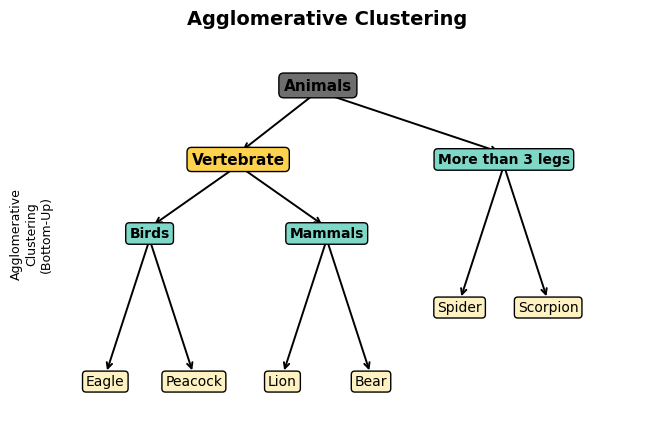

In [63]:
#  Plot the compact tree
# This draws the nodes using text boxes (rounded) and arrows using ax.annotate

def plot_compact_tree(positions, edges, leaves, title="Agglomerative Clustering"):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axis("off")
    xs = [p[0] for p in positions.values()]
    ys = [p[1] for p in positions.values()]
    xmin, xmax = min(xs) - 0.9, max(xs) + 0.9
    ymin, ymax = min(ys) - 0.6, max(ys) + 0.6
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    for parent, child in edges:
        if parent in positions and child in positions:
            x_parent, y_parent = positions[parent]
            x_child, y_child = positions[child]
            ax.annotate("",
                        xy=(x_child, y_child + 0.08), xycoords='data',
                        xytext=(x_parent, y_parent - 0.08), textcoords='data',
                        arrowprops=dict(arrowstyle="->", lw=1.4,
                                        color="black", shrinkA=4, shrinkB=4)
                        )
    for node, (x, y) in positions.items():
        if node in leaves:
            face = "#fff2c2"
            txtcol = "black"
            fontsize = 10
            pad = 0.25
        elif node == "Animals":
            face = "#6e6e6e"
            txtcol = "white"
            fontsize = 11
            pad = 0.32
        elif node == "Vertebrate":
            face = "#ffd24d"
            txtcol = "black"
            fontsize = 11
            pad = 0.30
        else:
            face = "#7fd8c7"
            txtcol = "black"
            fontsize = 10
            pad = 0.27
        ax.text(x, y, node, ha="center", va="center",
                fontsize=fontsize, weight="bold" if node not in leaves else "normal",
                bbox=dict(boxstyle="round,pad={}".format(pad),
                          facecolor=face, edgecolor="black"))
    ax.set_title(title, fontsize=14, weight="bold", pad=12)
    ax.text(xmin + 0.15, (ymin + ymax) / 2, "Agglomerative\nClustering\n(Bottom-Up)",
            ha="center", va="center", rotation=90, fontsize=9)
    try:
        out_path = "/mnt/data/agglomerative_compact.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved compact tree to: {out_path}")
    except Exception:
        pass
    plt.show()
plot_compact_tree(positions, edges, leaves)

# ✅ Key Advantages Observed During Implementation

One interesting observation while using hierarchical clustering was that the algorithm did not require predefined labels or categories.

Unlike methods such as K-Means, we were able to first visualize the relationships between points using the dendrogram and later decide the number of clusters.

Another important advantage was interpretability.

The dendrogram clearly showed:
- which points merged first
- which groups were highly similar
- and where major separation between clusters existed

This made the clustering process much more intuitive and easier to understand visually.

Additionally, hierarchical clustering is flexible because it can work with different distance metrics and linkage methods depending on the problem being solved.

# 🚀 Final Conclusion

In this notebook, we explored Hierarchical Clustering using a practical, step-by-step approach.

Instead of focusing only on theory, the goal was to understand:
- how clusters are formed
- how similarity is measured
- how dendrograms represent hierarchical relationships
- and why feature scaling is important in distance-based algorithms

Through visualization and implementation, we observed how Agglomerative Clustering groups similar data points together and gradually builds larger clusters based on distance.

We also learned:
- why the dendrogram rearranges points based on similarity
- how cluster separation appears visually
- and how scaling helps ensure fair distance calculations between features

This notebook helped build an intuitive understanding of hierarchical clustering before moving toward more advanced clustering techniques.